# Exercise 1

## 1 Loading the Dataset (2 points)


In [1]:
from sklearn . datasets import load_digits
digits = load_digits ()
print ( digits . keys () )
data = digits["data"]
images = digits["images"]
target = digits["target"]
target_names = digits["target_names"]
import numpy as np



dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [2]:
data_reduced = data[np.where((target == 3) | (target == 8))]
target_reduced = target[np.where((target == 3) | (target == 8))]

A = np.ones((data_reduced.shape[0],data_reduced.shape[1]+1))
A[:,1:] = data_reduced
data_reduced = A
ground_truth = np.where(target_reduced == 3, 1,-1)

print(data_reduced.shape)
print(ground_truth.shape)
print(len(data_reduced))

(357, 65)
(357,)
357


<div style="color: green; font-weight: bold">Good</div>

## 1.1 Classification with sklearn (6 Points)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold


from sklearn import model_selection
X,X_test,y ,y_test = model_selection.train_test_split(data_reduced,ground_truth,test_size = 0.3, random_state = 0)


C = [0.001,0.01,0.05,0.1,0.5,1,2,5,10,100]
splits = 4
Scores = np.zeros((splits,len(C)))
kf = KFold(n_splits=splits,shuffle = True)
n_s = 0

for train_index, validation_index in kf.split(y):
    #get the splits for the cross validation
    X_train,X_validation = X[train_index], X[validation_index]
    y_train, y_validation = y[train_index], y[validation_index]
    for n,c in enumerate(C):
        #train the LG algorithmus from sklearn 
        clf = LogisticRegression(random_state=1,max_iter=200, C=c).fit(X_train,y_train)
        score = np.sum((y_validation == clf.predict(X_validation))/len(y_validation))
        Scores[n_s,n] = score
    n_s += 1
    
for n,c in enumerate(C):
    print(f" mean accuracy for lambda = {c} : {np.round(np.mean(Scores[:,n],axis = 0),7)}")

print(f"max mean accuracy for lambda = {C[np.argmax(np.mean(Scores,axis = 0))]}")
#print(Scores)
lamb = C[np.argmax(np.mean(Scores,axis = 0))]#


 mean accuracy for lambda = 0.001 : 0.9758065
 mean accuracy for lambda = 0.01 : 0.983871
 mean accuracy for lambda = 0.05 : 0.983871
 mean accuracy for lambda = 0.1 : 0.983871
 mean accuracy for lambda = 0.5 : 0.983871
 mean accuracy for lambda = 1 : 0.983871
 mean accuracy for lambda = 2 : 0.983871
 mean accuracy for lambda = 5 : 0.9879032
 mean accuracy for lambda = 10 : 0.9879032
 mean accuracy for lambda = 100 : 0.9879032
max mean accuracy for lambda = 5


The best lambda according to the cross validation is inbetween 1 and 10. However I noticed that the difference between two different splits is much higher than the difference for different lambda.

<div style="color: green; font-weight: bold">Good, sample sol slightly neater due to cross_val_score</div>

## 1.2 Optimization Methods (20 Points)


In [4]:
#basic functions:
lamb = 5#choose lambda equals 5 


def sigmoid(z):
    return 1/(1+np.exp(-z))

def gradient(beta,X,y):
    a = beta
    #distinguish the two cases, where X is single sample and X are more samples
    if len(X.shape) == 2:
        L = len(X)
        b = lamb/L*(np.sum((sigmoid(-y*X.dot(beta))*(-(X.T*y).T).T).T,axis =0))
    else:
        L = 1
        b = lamb/L*(sigmoid(-y*X.dot(beta))*(-(X.T*y).T).T).T
    return a+b

def predict(beta,X):
    z = X.dot(beta)
    prob_1 = sigmoid(z)
    prob_m1 = sigmoid(-z)
    return np.where(prob_1 > prob_m1,1,-1)

def zero_one_loss(y_prediction, y_truth):
    return np.sum(1-(y_prediction == y_truth))/len(y_prediction)

def tau_t(tau_0,t,gamma):
    return tau_0/(1+gamma*t)

#function to get a list of m indicies for the data of length len(y). Used for the stochastic methods. The indicies are drawn
#without replacement. 
def get_single_index(m,y):
    index = np.zeros((int(m/len(y))+1)*len(y))
    for j in range((int(m/len(y))+1)): 
        index[j*len(y): (j+1)*len(y)] = np.random.choice(np.arange(0,len(y)),size = len(y),replace = False)
    return index.astype(int)

#function to get m/B lists of indicies of lenght B for the data X,y. Used for the SG_minibatch algorithm. The indicies are drawn 
#without replacement. 
def get_batch_index(m,B,y):
    index = np.zeros((int(m/len(y))+1)*len(y)*B)
    for j in range((int(len(index)/len(y)))):
        index[j*len(y): (j+1)*len(y)] = np.random.choice(np.arange(0,len(y)),size = len(y),replace = False)
        
    index = index[0:int(len(index)/B)*B]
    index = np.reshape(index,((int(len(index)/B)),B))
    return index.astype(int)
    

We chose to sample the indicies for the algorithms without replacement. On this way all data points are used. I would expect that this method is more stable, because one datapoint does not have as much influence that with replacement.

<div style="color: green; font-weight: bold">nitpicks 1) sigmoid in predict slightly useless, 2) if statement in gradient not the nicest (could have required the gradient to always be a matrix instead, 1xM matrix in stochastic case)</div>
<div style="color: green; font-weight: bold">Regarding get_single_index and get_batch_index: you can generate a permutation / indices with "samples = np.random.choice(y.shape[0], m, True)" and access the data by "X[samples]".</div>

In [5]:
#the algorithms are implemented such that they return the final beta for m iterations for the training data X,y and the 
#selected parameter. If save_history is set on True the full history of beta for each iteration is return. This feature was
#used for the speed comparison
def GD(m,X,y,beta_0,tau_0,save_history = False):
    beta = beta_0.copy()
    beta_history = []
    for i in range(m):
        beta_history.append(beta.copy())
        beta -= tau_0*gradient(beta,X,y)
    beta_history.append(beta.copy())
    if save_history:
        return beta_history
    else:
        return beta

    
def SG(m,X,y,beta_0,tau_0,gamma,save_history = False):
    beta = beta_0.copy()
    index = get_single_index(m,y)
    beta_history = []
    for i in range(m):
        beta_history.append(beta.copy())
        beta -= tau_t(tau_0,i,gamma)*gradient(beta,X[index[i]],y[index[i]])
    beta_history.append(beta.copy())
    if save_history:
        return beta_history
    else:
        return beta

def SG_minbat(m,X,y,beta_0,tau_0,gamma,B,save_history = False):
    beta = beta_0.copy()
    index = get_batch_index(m,B,y)
    beta_history = []
    for i in range(m):
        beta_history.append(beta.copy())
        beta -= tau_t(tau_0,i,gamma)*gradient(beta,X[index[i]],y[index[i]])
    
    beta_history.append(beta.copy())
    if save_history:
        return beta_history
    else:
        return beta

def SG_momentum(m,X,y,beta_0,tau_0,gamma,mu,save_history= False):
    beta = beta_0.copy()
    g = 0
    beta_history = []
    index = get_single_index(m,y)
    for i in range(m):
        beta_history.append(beta.copy())
        g = mu*g+(1-mu)*gradient(beta,X[index[i]],y[index[i]])
        beta -= tau_t(tau_0,i,gamma)*g

    beta_history.append(beta.copy())
    if save_history:
        return beta_history
    else:
        return beta

def ADAM(m,X,y,beta_0,save_history = False):#without replacement
    mu1 = 0.9
    mu2 = 0.999
    tau = 1e-4
    epsilon = 1e-8
    beta = beta_0.copy()
    g = 0
    q = 0
    index = get_single_index(m,y)
    beta_history = []
    #print(beta_0)
    for i in range(m):
        beta_history.append(beta.copy())
        g = mu1*g+(1-mu1)*gradient(beta,X[index[i]],y[index[i]])
        q = mu2*q+(1-mu2)*np.power(gradient(beta,X[index[i]],y[index[i]]),2)
        g_tilde = g/(1-mu1**(i+1))
        q_tilde = q/(1-mu2**(i+1))
        beta -= tau/(np.sqrt(q_tilde)+epsilon)*g_tilde
        
    beta_history.append(beta.copy())
    if save_history:
        return beta_history
    else:
        return beta
        

def SAG(m,X,y,beta_0,tau_0,gamma,save_history = False):
    g_stored = ((-y*sigmoid(-y*X.dot(beta_0)))*X.T).T
    g_0 = np.mean(g_stored,axis = 0)
    index = get_single_index(m,y)
    beta = beta_0.copy()
    g = g_0.copy()
    beta_history = []
    
    for i in range(m):
        beta_history.append(beta.copy())
        g_i = -y[index[i]]*X[index[i]]*sigmoid(-y[index[i]]*X[index[i]].dot(beta))
        g = g + 1/len(y)*(g_i-g_stored[index[i]])
        g_stored[index[i]] = g_i.copy()
        beta = beta*(1-tau_t(tau_0,i,gamma)/lamb)-tau_t(tau_0,i,gamma)*g

    beta_history.append(beta.copy())
    if save_history:
        return beta_history
    else:
        return beta

def dual_coord_asc(m,X,y,beta_0,save_history = False):
    alpha_0 = np.random.rand(len(y))
    beta_0 = lamb/len(y)*np.sum(((alpha_0*y)*X.T).T,axis = 0)
    
    index = get_single_index(m,y)
    beta = beta_0.copy()
    alpha = alpha_0.copy()
    alpha_1 = alpha.copy()
    beta_history = []
    
    for i in range(m):
        beta_history.append(beta.copy())
        f_1 = y[index[i]]*X[index[i]].dot(beta)+np.log(alpha[index[i]]/(1-alpha[index[i]]))
        f_2 = lamb/len(y)*X[index[i]].dot(X[index[i]])+1/(alpha[index[i]]*(1-alpha[index[i]]))
        alpha_1[index[i]] = alpha[index[i]]-f_1/f_2
        if alpha_1[index[i]] > 1:
            alpha_1[index[i]] = 1
        
        elif alpha_1[index[i]] < 0:
            alpha_1[index[i]] = 0
        beta += lamb/len(y)*y[index[i]]*X[index[i]]*(alpha_1[index[i]]-alpha[index[i]])
        alpha = alpha_1
    beta_history.append(beta.copy())
    if save_history:
        return beta_history
    else:
        return beta
        
    
def newton(m,X,y,beta_0,save_history = False):
    beta = beta_0.copy()
    beta_history = []
    for i in range(m):
        beta_history.append(beta.copy())
        z = X.dot(beta)
        y_tilde = y/(sigmoid(y.dot(z)))
        W = np.zeros((len(y),len(y)))
        W[np.arange(0,len(y),1),np.arange(0,len(y),1)] = lamb/len(y)*sigmoid(z)*sigmoid(-z)
        beta = np.linalg.inv(np.identity(len(X[0]))+X.T.dot(W.dot(X))).dot(X.T.dot(W)).dot(z+y_tilde)
    beta_history.append(beta.copy()) 
    if save_history:
        return beta_history
    else:
        return beta
    

<div style="color: green; font-weight: bold">Note: If you split up your code into multiple cells it is easier to comment.</div>
<div style="color: green; font-weight: bold">Regarding SAG: In your line "g_i = -y[index[i]]*X[index[i]]*sigmoid(-y[index[i]]*X[index[i]].dot(beta))" you may have forgotten one transpose of X: "g_i = -y[index[i]]*X[index[i]].T*sigmoid(-y[index[i]]*X[index[i]].dot(beta))". I also do not understand how you computed g_stored. It looks different from the exercise. We used: "g_stored = np.array([-y[i] * X[i].T * sigmoid(-y[i] * X[i].dot(beta_initial)) for i in range(y.shape[0])])"</div>
<div style="color: green; font-weight: bold">Regarding dual_coord_asc: you can use np.clip to limit the values to a specified range. In the line: "beta += lamb/len(y)*y[index[i]]*X[index[i]]*(alpha_1[index[i]]-alpha[index[i]])" you might also have forgotten a transpose of X</div>


## 1.3 Comparison (12 Points)


In [6]:
from sklearn import model_selection
X,X_test,y ,y_test = model_selection.train_test_split(data_reduced,ground_truth,test_size = 0.3, random_state = 0)


In [7]:
tau = [0.001,0.01,0.1]
gamma = [0.0001,0.001,0.01]


In [8]:
#funciton to test a method form above and write the performance in a list
def test_method(method,parameter,testfile):
    beta = method(*parameter)
    performance = zero_one_loss(y_validation,predict(beta,X_validation))
    testfile[i] += performance/splits


from sklearn.model_selection import KFold

#parameters for the corss validation
splits = 10
kf = KFold(n_splits=splits,shuffle = True)
tau = [0.001,0.01,0.1]
mu = [0.1,0.2,0.5]
gamma = [0.0001,0.001,0.01]
B = [5,25,50]
m_stochastic = 150
m = 10

#all combination of the parameters defined above are tested on the same splits of the training data.

#get permutations of the parameters used for each method
GD_parameter = tau
GD_test = np.zeros(len(GD_parameter))

x = np.meshgrid(tau,gamma)
SG_parameter = [x[0].flatten(),x[1].flatten()]
SG_test = np.zeros(len(SG_parameter[0]))

x = np.meshgrid(tau,gamma,B)
SG_minbat_parameter = [x[0].flatten(),x[1].flatten(),x[2].flatten()]
SG_minbat_test = np.zeros(len(SG_minbat_parameter[0]))
    
x = np.meshgrid(tau,gamma,mu)
SG_mom_parameter = [x[0].flatten(),x[1].flatten(),x[2].flatten()]
SG_mom_test = np.zeros(len(SG_mom_parameter[0]))

ADAM_parameter = np.ones(1)
ADAM_test = np.zeros(1)

x = np.meshgrid(tau,gamma)
SAG_parameter = [x[0].flatten(),x[1].flatten()]
SAG_test = np.zeros(len(SAG_parameter[0]))

dual_coord_asc_parameter = np.ones(1)
dual_coord_asc_test = np.zeros(1)

newton_parameter = np.ones(1)
newton_test = np.zeros(1)

#loop over the splits and for each split in a second loop the methods are trained and tested with all parameter combinations
for train_index, validation_index in kf.split(y):
    X_train,X_validation = X[train_index], X[validation_index]
    y_train, y_validation = y[train_index], y[validation_index]
    beta_0 = np.zeros(X_train.shape[1])
    
    
    for i in range(30):
        
        if i <= len(GD_parameter)-1:

            test_method(GD,[m,X_train,y_train,beta_0,GD_parameter[i]],GD_test)
        
        if i <= len(SG_parameter[0])-1:

            test_method(SG,[m_stochastic,X_train,y_train,beta_0,SG_parameter[0][i],SG_parameter[1][i]],SG_test)
            
        if i <= len(SG_minbat_parameter[0])-1:

            test_method(SG_minbat,[m_stochastic,X_train,y_train,beta_0,SG_minbat_parameter[0][i],SG_minbat_parameter[1][i],SG_minbat_parameter[2][i]],SG_minbat_test)

        if i <= len(SG_mom_parameter[0])-1:

            test_method(SG_momentum,[m_stochastic,X_train,y_train,beta_0,SG_mom_parameter[0][i],SG_mom_parameter[1][i],SG_mom_parameter[2][i]],SG_mom_test)
        
        if i <= len(ADAM_parameter)-1:

            test_method(ADAM,[m_stochastic,X_train,y_train,beta_0],ADAM_test)#
        
        if i <= len(SAG_parameter[0])-1:

            test_method(SAG,[m_stochastic,X_train,y_train,beta_0,SAG_parameter[0][i],SAG_parameter[1][i]],SAG_test)
            
        if i <= len(dual_coord_asc_parameter)-1:

            test_method(dual_coord_asc,[m_stochastic,X_train,y_train,beta_0],dual_coord_asc_test)
            
        if i <= len(newton_parameter)-1:
            test_method(newton,[m,X_train,y_train,beta_0],newton_test)
        



/tmp/ipykernel_39432/2329069172.py:6: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


In [9]:
print("GD - algo")
print(f"best parameter : (tau) =  ({GD_parameter[np.argmin(GD_test)]})\n "
      f"with validation error : {np.round(np.min(GD_test),5)}")
print("-----")
print("SG - algo")
print(f"best parameter : (tau_0, gamma) =  ({SG_parameter[0][np.argmin(SG_test)],SG_parameter[1][np.argmin(SG_test)]})\n "
      f"with validation error : {np.round(np.min(SG_test),5)}")
print("-----")
print("SG_minibatch - algo")
print(f"best parameter : (tau_0, gamma, B) =  ({SG_minbat_parameter[0][np.argmin(SG_minbat_test)],SG_minbat_parameter[1][np.argmin(SG_minbat_test)],SG_minbat_parameter[2][np.argmin(SG_minbat_test)]})\n "
      f"with validation error : {np.round(np.min(SG_minbat_test),5)}")
print("-----")
print("SG_momentum - algo")
print(f"best parameter : (tau_0, gamma, mu) =  ({SG_mom_parameter[0][np.argmin(SG_mom_test)],SG_mom_parameter[1][np.argmin(SG_mom_test)],SG_mom_parameter[2][np.argmin(SG_mom_test)]})\n "
      f"with validation error : {np.round(np.min(SG_mom_test),5)}")
print("-----")
print("ADAM - algo")
print(f"with validation error : {np.round(np.min(ADAM_test),5)}")
print("-----")
print("stochastic average gradient - algo")
print(f"best parameter : (tau_0, gamma) =  ({SAG_parameter[0][np.argmin(SAG_test)],SAG_parameter[1][np.argmin(SAG_test)]})\n "
      f"with validation error : {np.round(np.min(SAG_test),5)}")
print("-----")
print("dual coordinate ascent - algo")
print(f"with validation error : {np.round(np.min(dual_coord_asc_test),5)}")
print("-----")
print("Newton/Raphson - algo")
print(f"with validation error : {np.round(np.min(newton_test),5)}")

#save the best working parameter form the cross validation in a list
GD_best_parameter = [GD_parameter[np.argmin(GD_test)]]
SG_best_parameter = [SG_parameter[0][np.argmin(SG_test)],SG_parameter[1][np.argmin(SG_test)]]
SG_minbat_best_parameter = [SG_minbat_parameter[0][np.argmin(SG_minbat_test)],SG_minbat_parameter[1][np.argmin(SG_minbat_test)],SG_minbat_parameter[2][np.argmin(SG_minbat_test)]]
SG_momentum_best_parameter = [SG_mom_parameter[0][np.argmin(SG_mom_test)],SG_mom_parameter[1][np.argmin(SG_mom_test)],SG_mom_parameter[2][np.argmin(SG_mom_test)]]
SAG_best_parameter = [SAG_parameter[0][np.argmin(SAG_test)],SAG_parameter[1][np.argmin(SAG_test)]]

GD - algo
best parameter : (tau) =  (0.001)
 with validation error : 0.06417
-----
SG - algo
best parameter : (tau_0, gamma) =  ((0.001, 0.01))
 with validation error : 0.06067
-----
SG_minibatch - algo
best parameter : (tau_0, gamma, B) =  ((0.001, 0.01, 5))
 with validation error : 0.01617
-----
SG_momentum - algo
best parameter : (tau_0, gamma, mu) =  ((0.001, 0.01, 0.2))
 with validation error : 0.02017
-----
ADAM - algo
with validation error : 0.11683
-----
stochastic average gradient - algo
best parameter : (tau_0, gamma) =  ((0.1, 0.0001))
 with validation error : 0.04817
-----
dual coordinate ascent - algo
with validation error : 0.1405
-----
Newton/Raphson - algo
with validation error : 0.0205


The results above show the mean validations error for a constant set of tested parameter. The best working parameter and the best validation error are printed. All algorithms except the dual coordinate ascent converge to a decent validation error blow 10%. The lowest error is achieved by the SG_minibatch and the newton/Raphson algorithm with 1.2%. 
All methods are tested and trained with the same splits of the data. As a result the differences between the methods in the validation error comes from the method and not from different splits. However the sampling of the data for the iterations is for each method different.  

<div style="color: green; font-weight: bold">Looks correct, though a bit tedious. However, other than the sample solution, this doesn't require defining all of mu,gamma,tau0 even if the method doesn't require it. In this way, this is much preferable to how the sample solution goes about this..</div>

In [10]:
algo_names = ["gradient descent", "stochastic gradient", "SG minibatch", "SG momentum", "ADAM", "stochastic average gradient",
             "dual coordinate ascent", "Newton/Raphson"]
algo = [GD, SG, SG_minbat, SG_momentum, ADAM, SAG, dual_coord_asc, newton]
parameter = [GD_best_parameter, SG_best_parameter, SG_minbat_best_parameter, SG_momentum_best_parameter, [],SAG_best_parameter,[],[]]
complexity = [len(y)*len(X[0]),len(X[0]),len(X[0])*SG_minbat_best_parameter[2],len(X[0]),len(X[0]),len(X[0]),len(X[0]),len(y)*len(X[0])**2]
test_error = [[],[],[],[],[],[],[],[]]
train_error = [[],[],[],[],[],[],[],[]]
T = [[],[],[],[],[],[],[],[]]
iteration = [[],[],[],[],[],[],[],[]]
beta_list = []

In [11]:
#the methods are now trained again with the full training set with the best working parameters from above
#for 300 iterations and the history of beta is saved.
#The performacne is then calculated for each beta.

m = 150
for n,method in enumerate(algo):
    beta = method(m,X,y,np.zeros(X.shape[1]),*parameter[n], True)
    beta_list.append(beta)
    for t,b in enumerate(beta):
        ER_test = zero_one_loss(y_test,predict(b,X_test))
        ER_train = zero_one_loss(y,predict(b,X))
        test_error[n].append(ER_test.copy())
        train_error[n].append(ER_train.copy())
        iteration[n].append(t)
        T[n].append(complexity[n]*t)
        


/tmp/ipykernel_39432/2329069172.py:6: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


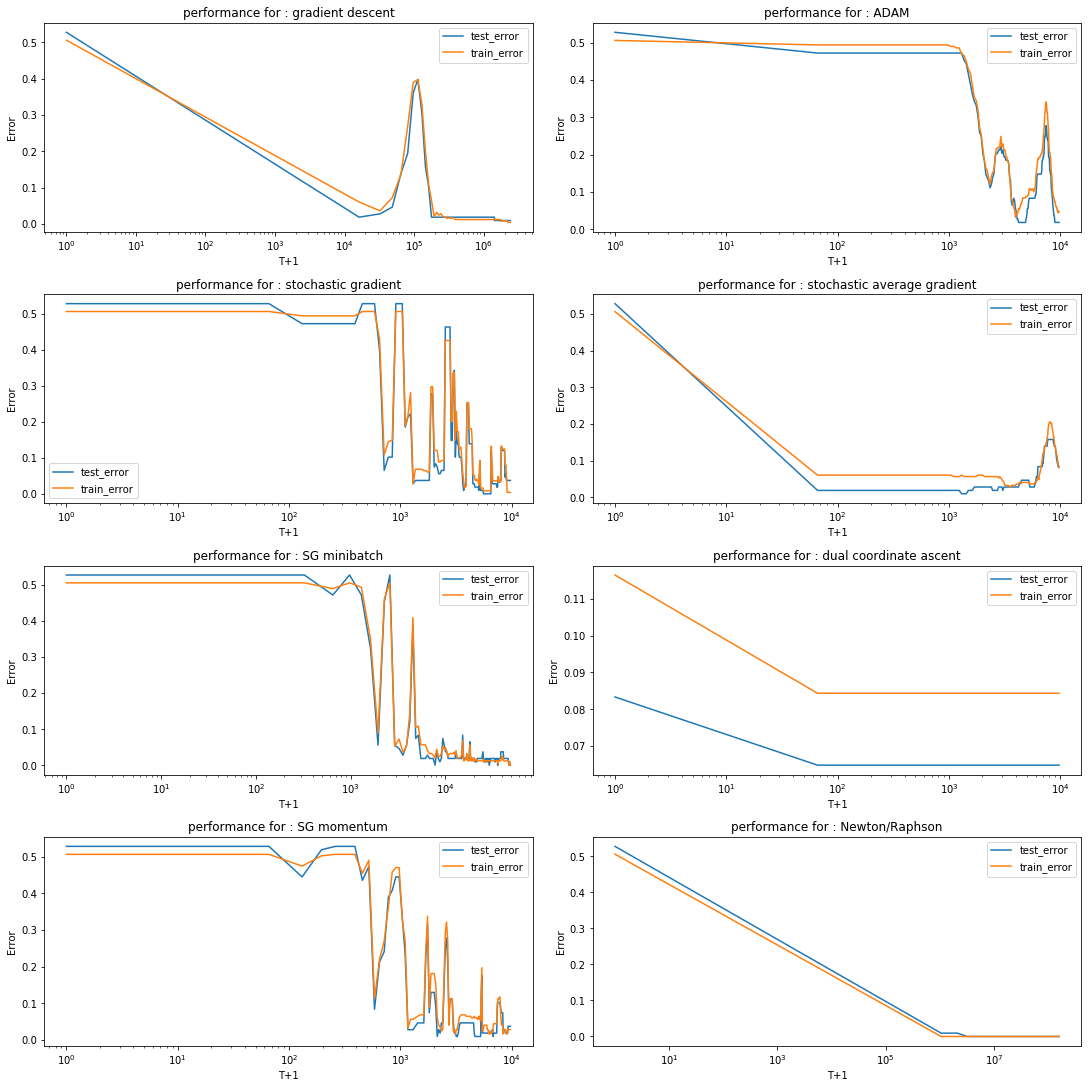

In [12]:
import matplotlib.pyplot as plt
x_ax = 4
y_ax = 2
fig,axs = plt.subplots(x_ax,y_ax,constrained_layout = True)
fig.set_size_inches((15,15))
for n,x_data in enumerate(T):
    i = int(n/x_ax)
    j = n-i*x_ax
    #print(x_data)
    x_data = np.array(x_data)
    axs[j][i].plot(x_data+1,test_error[n],label = "test_error")
    axs[j][i].plot(x_data+1,train_error[n],label = "train_error")
    axs[j][i].set_title(f"performance for : {algo_names[n]}")
    axs[j][i].legend()
    axs[j][i].set_xlabel("T+1")
    axs[j][i].set_ylabel("Error")
    #axs[j][i].set_xlim(0,10000)
    axs[j][i].set_xscale('log')
    
    
plt.show()

The plots above show the training and validation error calculated after each iteration for each method. The error is plotted against the time T which is the product of the number of iterations and the complexity of each iteration. In addition T+1 is used to show the performance of the initial beta in a log plot. The fastest converging alogorithm is stochastic average gradient with O(T) = 100. After one iteration the convergence is reached just like in the newton algorithm. However the complexity of one iteration is for the newton algo much higher. It is suspicious that for the SG moment, stochastic gradient, gradient decent and sometimes for ADAM the error function is not monotonical decreasing. It seems like the algorithms are oscillating around the best solution. One reason for this behaviour could be a step size that is too large or a too large t_zero or too small Gamma for the stochastic methods. Another indication for a bug ist the plot for the dual coordinate ascent with stayes constant for each iteration.

<div style="color: green; font-weight: bold">Your plots would have benefitted from shared x and y axes to really make the difference between algs clear. However, your discussion looks right and the plots are informative as well, good job.</div>